In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
df = pd.read_csv("../data/stores_sales_forecasting.csv", encoding="latin1")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [4]:
print("Shape of Dataset :", df.shape)
print("\nColumns :\n")
print(df.columns)

print("\nData Types\n")
print(df.dtypes)

Shape of Dataset : (2121, 21)

Columns :

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

Data Types

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [5]:
print("Missing Values")

print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

df = df.drop_duplicates()

print("\nDuplicates Removed Successfully")

Missing Values
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate Rows : 0

Duplicates Removed Successfully


In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

print(df[['Order Date']].head())

  Order Date
0 2016-11-08
1 2016-11-08
2 2015-10-11
3 2014-06-09
4 2014-06-09


In [7]:
sales_data = df.groupby('Order Date')['Sales'].sum().reset_index()

sales_data.head()

,Order Date,Sales
0,2014-01-06,2573.820
1,2014-01-07,76.728
2,2014-01-10,51.940
3,2014-01-11,9.940
4,2014-01-13,879.939


In [8]:
print(sales_data.info())

print("\n")

sales_data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  889 non-null    datetime64[us]
 1   Sales       889 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 14.0 KB
None




,Order Date,Sales
count,889,889.000000
mean,2016-03-02 02:41:58.785151,834.645439
min,2014-01-06 00:00:00,1.988000
25%,2015-03-08 00:00:00,173.940000
50%,2016-03-29 00:00:00,493.920000
75%,2017-03-16 00:00:00,1128.390000
max,2017-12-30 00:00:00,10006.174000
std,NaN,1015.317163


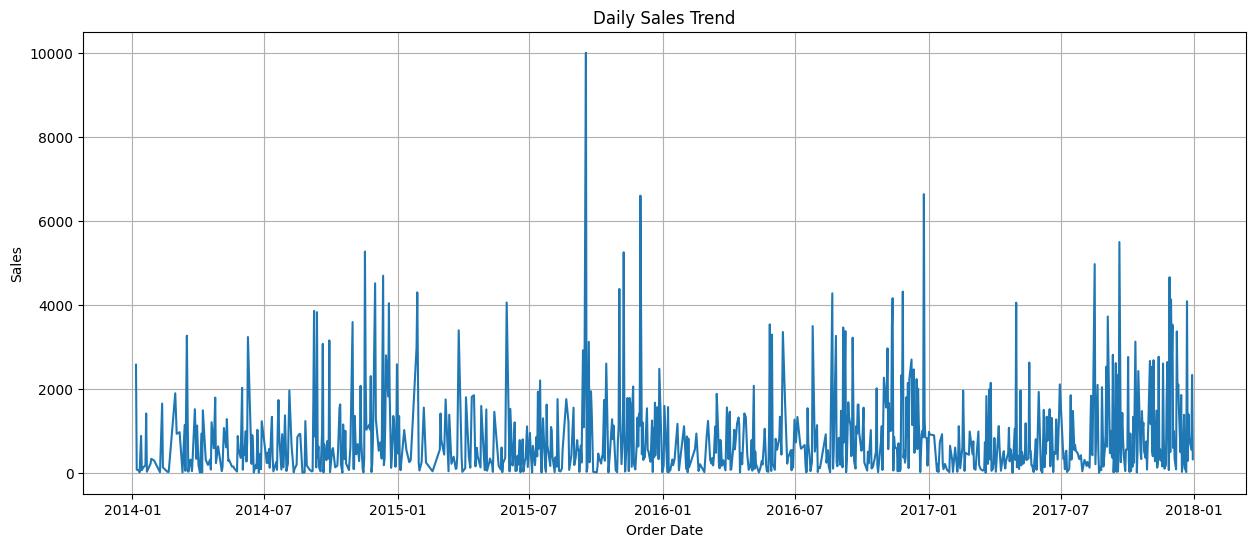

In [9]:
plt.figure(figsize=(15,6))

plt.plot(
    sales_data['Order Date'],
    sales_data['Sales']
)

plt.title("Daily Sales Trend")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [10]:
sales_data = sales_data.sort_values("Order Date")

sales_data["Day_Number"] = np.arange(len(sales_data))

sales_data.head()

,Order Date,Sales,Day_Number
0,2014-01-06,2573.820,0
1,2014-01-07,76.728,1
2,2014-01-10,51.940,2
3,2014-01-11,9.940,3
4,2014-01-13,879.939,4


In [11]:
X = sales_data[['Day_Number']]

y = sales_data['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=False
)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (711, 1)
Testing Shape : (178, 1)


In [12]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [13]:
y_pred = model.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [14]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 759.378178958405
RMSE : 1057.1154484586593
R2 Score : -0.0102482533542132


In [15]:
comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,1179.670,844.490668
1,303.544,844.616271
2,342.000,844.741874
3,2624.580,844.867477
4,525.252,844.993080
5,520.050,845.118683
6,181.986,845.244285
7,171.288,845.369888
8,18.840,845.495491
9,512.300,845.621094


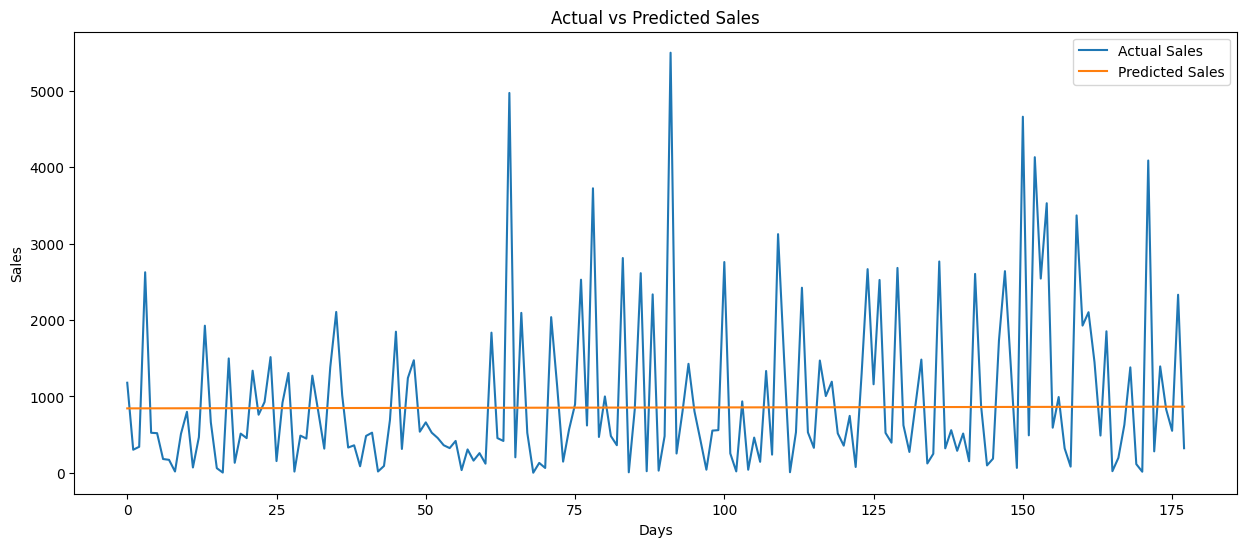

In [16]:
plt.figure(figsize=(15,6))

plt.plot(y_test.values, label="Actual Sales")

plt.plot(y_pred, label="Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.xlabel("Days")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [17]:
future_days = 30

last_day = sales_data['Day_Number'].max()

future_day_numbers = np.arange(last_day + 1, last_day + future_days + 1)

future_predictions = model.predict(future_day_numbers.reshape(-1,1))

c:\Users\rames\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [18]:
future_dates = pd.date_range(
    start=sales_data['Order Date'].max() + pd.Timedelta(days=1),
    periods=future_days
)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted Sales": future_predictions
})

forecast_df

,Date,Forecasted Sales
0,2017-12-31,866.847982
1,2018-01-01,866.973585
2,2018-01-02,867.099187
3,2018-01-03,867.224790
4,2018-01-04,867.350393
5,2018-01-05,867.475996
6,2018-01-06,867.601599
7,2018-01-07,867.727202
8,2018-01-08,867.852805
9,2018-01-09,867.978408


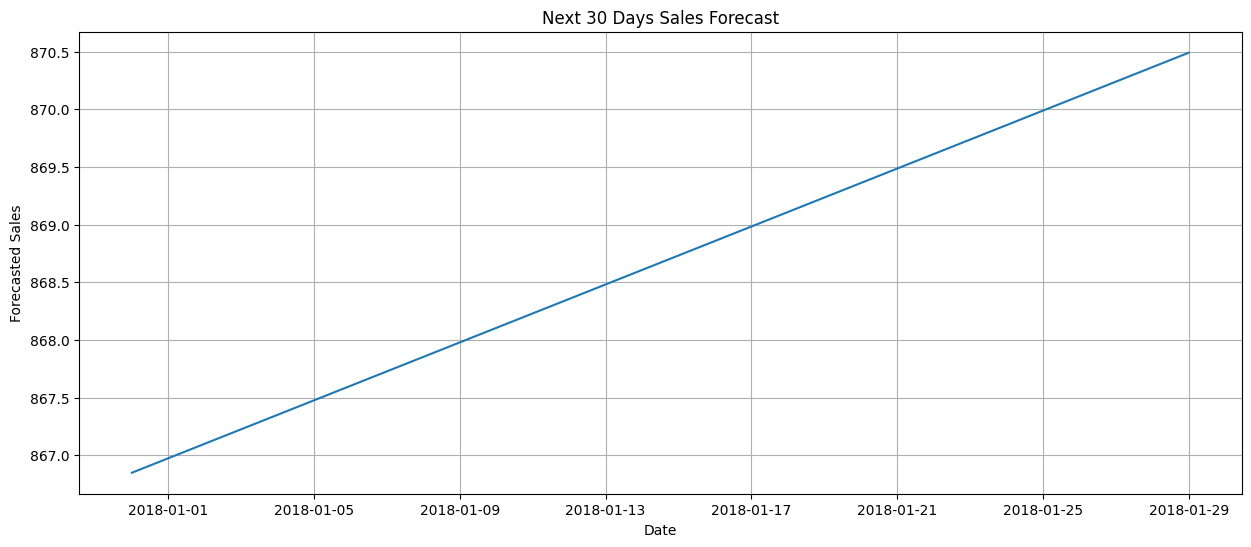

In [19]:
plt.figure(figsize=(15,6))

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecasted Sales"]
)

plt.title("Next 30 Days Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Forecasted Sales")

plt.grid(True)

plt.show()

In [20]:
forecast_df.to_csv("../output/sales_forecast.csv", index=False)

print("Forecast saved successfully!")

Forecast saved successfully!


In [21]:
print("========== BUSINESS INSIGHTS ==========")

print()

print("1. Sales trend analyzed successfully.")

print("2. Machine Learning model trained.")

print("3. Future 30-day sales forecast generated.")

print("4. Forecast saved in output folder.")

print()

print("========== PROJECT COMPLETED ==========")

========== BUSINESS INSIGHTS ==========

1. Sales trend analyzed successfully.
2. Machine Learning model trained.
3. Future 30-day sales forecast generated.
4. Forecast saved in output folder.

========== PROJECT COMPLETED ==========
